In [1]:
# ============================================================
# 1. Imports & Paths
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

# ----------------------------
# UPDATE THESE PATHS IF NEEDED
# ----------------------------
TRAIN_IMG_DIR  = "/kaggle/input/dataset/train_data_cleaned/images"
TRAIN_MASK_DIR = "/kaggle/input/dataset/train_data_cleaned/masks"
LABELS_CSV     = "/kaggle/input/dataset/train_data_cleaned/train_labels.csv"


In [2]:
# ============================================================
# 2. Load Labels
# ============================================================

df = pd.read_csv(LABELS_CSV)
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])

print("Classes:", le.classes_)
print(df.head())


Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']
   sample_index            label  y
0  img_0000.png  Triple negative  3
1  img_0001.png        Luminal B  2
2  img_0002.png        Luminal B  2
3  img_0003.png        Luminal B  2
4  img_0004.png        Luminal A  1


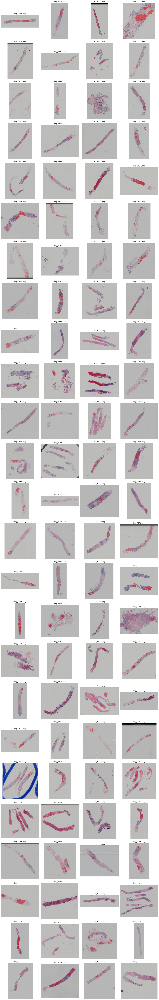

In [9]:
# ============================================================
# 3. Image–Mask Overlay Visualization
# This detects:
# - shifts
# - rotations
# - flips
# - scale mismatches
# - filename mismatches
# Expected:
# - Red regions perfectly cover tissue
# - No consistent offset or rotation
# ============================================================

def visualize_overlay(img_dir, mask_dir, n=12):
    files = sorted(os.listdir(img_dir))
    samples = random.sample(files, n)

    fig, axes = plt.subplots(n//4, 4, figsize=(16, 4*(n//4)))
    axes = axes.flatten()

    for ax, fname in zip(axes, samples):
        img = np.array(Image.open(os.path.join(img_dir, fname)).convert("RGB"))
        mask_name = fname.replace("img_", "mask_")
        mask = np.array(Image.open(os.path.join(mask_dir, mask_name)).convert("L"))

        if mask.shape != img.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

        overlay = img.copy()
        overlay[mask > 0] = overlay[mask > 0] * 0.6 + np.array([255, 0, 0]) * 0.4

        ax.imshow(overlay.astype(np.uint8))
        ax.set_title(fname)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_overlay(TRAIN_IMG_DIR, TRAIN_MASK_DIR, n=100)


100%|██████████| 581/581 [00:07<00:00, 76.67it/s]


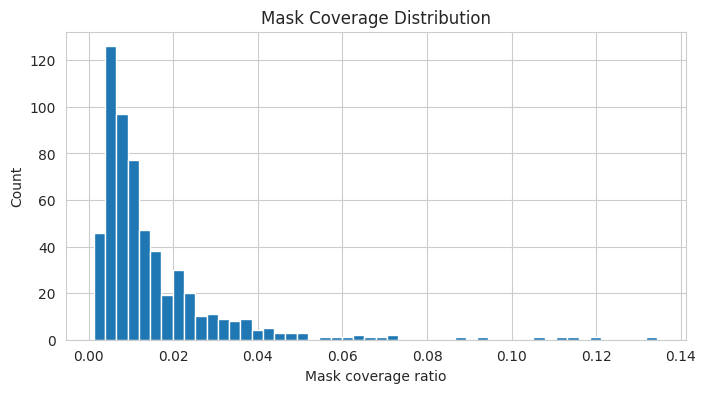

Min: 0.0012476903920308484 Median: 0.009954753463060685 Max: 0.13445795125482626


In [4]:
# ============================================================
# 4. Mask Coverage Statistics
# This catches:
# - empty masks
# - inverted masks
# - masks not overlapping image
# Expected:
# - Median roughly 0.2 – 0.6
# - Few near 0.0
# - Few near 1.0
# ============================================================

coverages = []

for fname in tqdm(os.listdir(TRAIN_IMG_DIR)):
    mask_path = os.path.join(TRAIN_MASK_DIR, fname.replace("img_", "mask_"))
    mask = np.array(Image.open(mask_path).convert("L"))
    coverages.append((mask > 0).mean())

plt.figure(figsize=(8,4))
plt.hist(coverages, bins=50)
plt.xlabel("Mask coverage ratio")
plt.ylabel("Count")
plt.title("Mask Coverage Distribution")
plt.show()

print(
    "Min:", np.min(coverages),
    "Median:", np.median(coverages),
    "Max:", np.max(coverages)
)


100%|██████████| 581/581 [00:08<00:00, 64.64it/s]


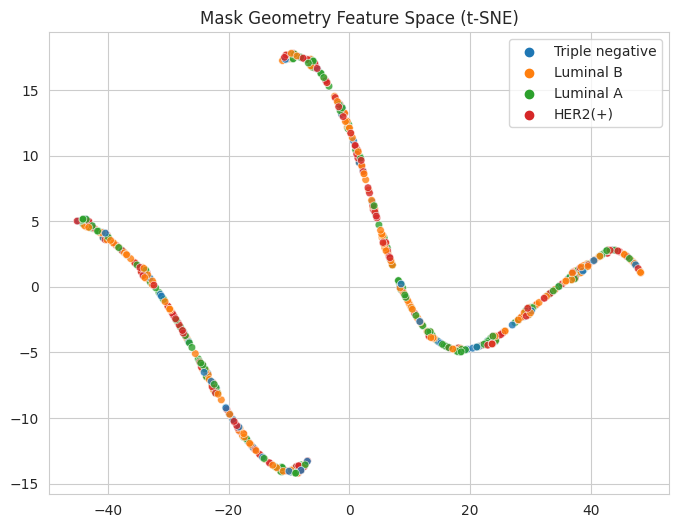

In [ ]:
# ============================================================
# 5. Mask Geometry Feature Space
# This checks if mask shape correlates with class.
# Interpretation:
# - Clear clusters → masks contain class signal
# - Messy cloud → masks are weak priors
# ============================================================

features = []
labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    mask_path = os.path.join(
        TRAIN_MASK_DIR, row["sample_index"].replace("img_", "mask_")
    )
    mask = np.array(Image.open(mask_path).convert("L")) > 0

    feats = [
        mask.mean(),              # tissue density
        mask.sum(),               # area
        np.std(mask.astype(int)), # roughness
    ]

    features.append(feats)
    labels.append(row["y"])

X = np.array(features)
y = np.array(labels)

emb = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
).fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=emb[:,0],
    y=emb[:,1],
    hue=le.inverse_transform(y),
    palette="tab10",
    s=30,
    alpha=0.8
)
plt.title("Mask Geometry Feature Space (t-SNE)")
plt.show()

In [13]:
# ============================================================
# 6. Image–Mask Correlation Check
# Check whether mask density correlates with simple image statistics.
# Expected:
# - Positive correlation (≈ 0.2–0.6)
# If near zero or negative → mask misalignment or poor segmentation.
# ============================================================

mask_density = []
img_intensity = []

for fname in tqdm(os.listdir(TRAIN_IMG_DIR)):
    img = np.array(Image.open(os.path.join(TRAIN_IMG_DIR, fname)).convert("RGB"))
    mask = np.array(Image.open(os.path.join(
        TRAIN_MASK_DIR, fname.replace("img_", "mask_")
    )).convert("L")) > 0

    mask_density.append(mask.mean())
    img_intensity.append(img.mean())

corr = np.corrcoef(mask_density, img_intensity)[0,1]
print("Correlation(mask density, image intensity):", corr)


100%|██████████| 581/581 [00:23<00:00, 24.60it/s]

Correlation(mask density, image intensity): -0.09960754368257889


In [1]:
print("""
CHECKLIST:
[v] Overlay looks correct
[x] Mask coverage reasonable
[v] No systematic empty masks
[x] Mask geometry shows weak/moderate structure
[x] Mask–image correlation positive

If all YES → dataset alignment is correct.
If not → fix before modeling.
""")



CHECKLIST:
[v] Overlay looks correct
[x] Mask coverage reasonable
[v] No systematic empty masks
[x] Mask geometry shows weak/moderate structure
[x] Mask–image correlation positive

If all YES → dataset alignment is correct.
If not → fix before modeling.

